In [1]:
from fastscape.models import basic_model
import numpy as np
import matplotlib.pyplot as plt
%load_ext xsimlab.ipython

# Notebook 3
How to make a parameter a function of space

In [2]:
# %create_setup basic_model -v -d
import xsimlab as xs

tf = 5e6
nstep = 101
ds_in = xs.create_setup(
    model=basic_model,
    clocks={'time':np.linspace(0,tf,nstep)},
    input_vars={
        # nb. of grid nodes in (y, x)
        'grid__shape':[101,201],
        # total grid length in (y, x)
        'grid__length':[10e3,20e3],
        # node status at borders
        'boundary__status': 'fixed_value',
        # uplift rate
        'uplift__rate': 1e-3, 
        # bedrock channel incision coefficient
        'spl__k_coef': 1e-5,
        # drainage area exponent
        'spl__area_exp': 0.45,
        # slope exponent
        'spl__slope_exp': 1,
        # diffusivity (transport coefficient)
        'diffusion__diffusivity':0.1 ,
        # random seed
        'init_topography__seed': None,
    },
    output_vars={'topography__elevation':'time',
                 'drainage__area':'time'}
)


In [3]:
import xarray as xr
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in.xsimlab.run())

             0% | initialize 

To define a function of space, we must define coordinates (x and y), two arrays of dimensions (ny,nx) that contains the coordinates of all the points on the grid. Note that we give to this arrays coordinates named 'x' and 'y'. This will allow us to create arrays with proper coordinates to include into ds_in 

In [4]:
ds_in.grid__length
ds_in.grid__shape
x,y = np.meshgrid(np.linspace(0,ds_in.grid__length[1],ds_in.grid__shape[1].values),
                  np.linspace(0,ds_in.grid__length[0],ds_in.grid__shape[0].values))

x = xr.DataArray(x, dims=('y','x'))
y = xr.DataArray(y, dims=('y','x'))


We use the coordinate y to define an asymmetric uplift function that increaseslinearly with increasing values of y. Note that we chose this function such that the mean remains equal to 1e-3 (what we used in the previous run with a uniform uplif rate)

In [5]:
import xarray as xr
with basic_model, xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.update_vars(input_vars={'uplift__rate': 0.8e-3+0.4e-3*y/y.max()})
              .xsimlab.run())

             0% | initialize 

We see taht the resulting topography has a strong asymmetry

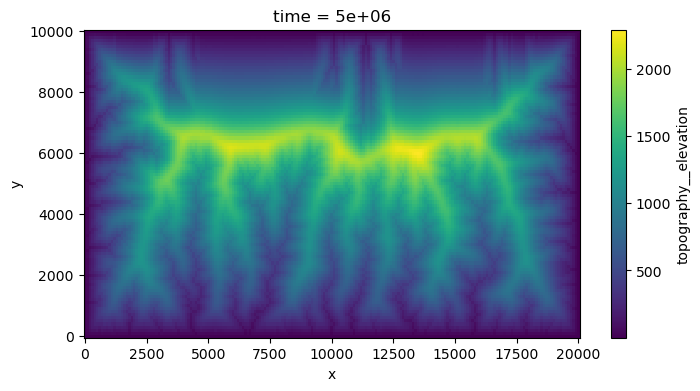

In [6]:
ds_out.topography__elevation.isel(time=-1).plot(size=4, aspect=2);

Let's try to explain it. We check first that the system has reached steady-state.

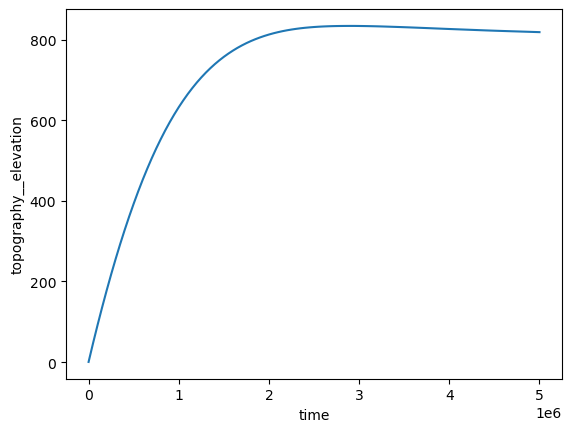

In [7]:
ds_out.topography__elevation.mean(('x','y')).plot()

If we plot the topography averaged in the x dirtection we see that slope is greater on the north side

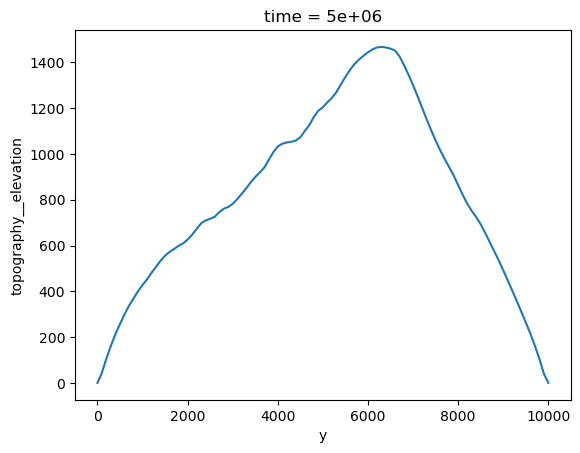

In [8]:
ds_out.topography__elevation.mean('x').isel(time=-1).plot();

But drainage area is largest on the south side

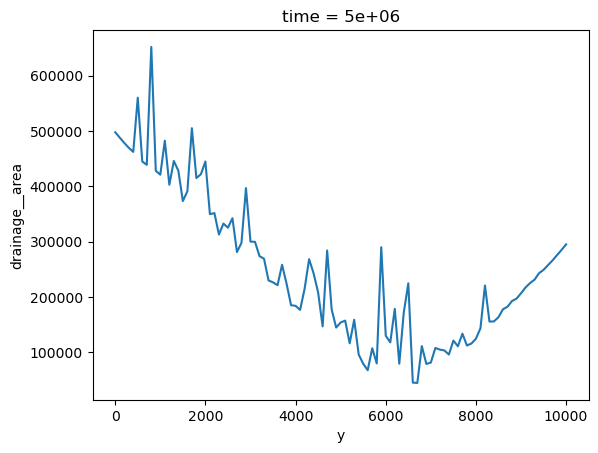

In [9]:
ds_out.drainage__area.mean('x').isel(time=-1).plot();

The asymmetry is explained by the difference in th e exponent $m$ and $n$ in the stream power law. Indeed at steady-state $$U=K_fA^mS^n$$. In the north the slope is larger but the area is smaller, while in the south, it is the opposite. It is therefore not clear why a steeper slope is best to balance a faster uplift. This is only true if $n>n$.

We now check that the asymmetry does not arise form the initial condition by adding a symmetrical initial topography

In [13]:
import xarray as xr
with basic_model.drop_processes('init_topography'), xs.monitoring.ProgressBar():
    ds_out = (ds_in
              .xsimlab.update_vars(input_vars={'uplift__rate': 0.8e-3+0.4e-3*y/y.max(),
                                               'topography__elevation':
                                                xr.where(y<y.max()/2,
                                                         y/(y.max()/2)*100,
                                                         (y.max()-y)/(y.max()/2)*100)
                                                +np.random.random(y.shape),
                                                'boundary__status':['looped','looped','fixed_value','fixed_value']
                                                })
              .xsimlab.update_clocks(clocks={'time':np.linspace(0,2*tf,201)})
              .xsimlab.run())

             0% | initialize 

And we see that we still obtain an asymmetrical solution but not as well developed

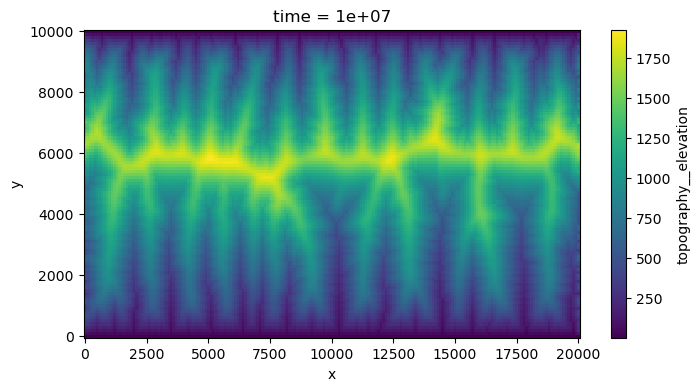

In [14]:
ds_out.topography__elevation.isel(time=-1).plot(size=4, aspect=2);

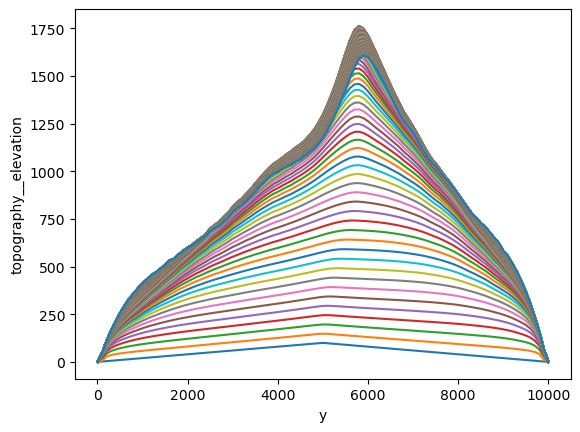

In [15]:
ds_out.topography__elevation.mean('x').plot.line(x='y', add_legend=False);